# Yelp Dataset EDA - Project Feasibility Check
## Restaurant Hype Networks: Influence, Homophily, and Cluster Dynamics

**Setup:**
1. Download Yelp Open Dataset from https://www.yelp.com/dataset
2. Update `DATA_PATH` below
3. `pip install pandas networkx matplotlib seaborn tqdm`
4. Run cells in order

## Section 0: Imports & Configuration

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import threading
import time
from collections import Counter, defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# UPDATE THESE PATHS
# ============================================================
DATA_PATH = '/Users/andykim/Downloads/Yelp JSON/yelp_dataset/'  # <-- Your extracted folder
TARGET_CITY = 'Philadelphia'

# Output folder for plots (saves to Desktop by default)
OUTPUT_DIR = os.path.expanduser('~/Desktop/yelp_eda_output/')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Plots will be saved to: {OUTPUT_DIR}')

# File paths
BUSINESS_FILE = DATA_PATH + 'yelp_academic_dataset_business.json'
REVIEW_FILE   = DATA_PATH + 'yelp_academic_dataset_review.json'
USER_FILE     = DATA_PATH + 'yelp_academic_dataset_user.json'
CHECKIN_FILE  = DATA_PATH + 'yelp_academic_dataset_checkin.json'
TIP_FILE      = DATA_PATH + 'yelp_academic_dataset_tip.json'

# Heartbeat utility for long operations
class Heartbeat:
    def __init__(self, message='Still working', interval=10):
        self.message = message
        self.interval = interval
        self.running = False
        self.thread = None
        self.start_time = None

    def _beat(self):
        while self.running:
            time.sleep(self.interval)
            if self.running:
                elapsed = int(time.time() - self.start_time)
                print(f'  \U0001f493 {self.message}... ({elapsed}s elapsed)')

    def start(self):
        self.running = True
        self.start_time = time.time()
        self.thread = threading.Thread(target=self._beat, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False
        elapsed = int(time.time() - self.start_time)
        print(f'  \u2705 Done! ({elapsed}s)')

# Helper to load small JSON files
def load_json_lines(filepath, max_lines=None):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f, desc=f'Loading {filepath.split("/")[-1]}')):
            if max_lines and i >= max_lines:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

print('\u2705 Setup complete!')

Plots will be saved to: /Users/andykim/Desktop/yelp_eda_output/
✅ Setup complete!


## Section 1: Business Data — Which cities work?

In [6]:
print('=' * 70)
print('SECTION 1: BUSINESS DATA OVERVIEW')
print('=' * 70)

business_df = load_json_lines(BUSINESS_FILE)
print(f'\nTotal businesses: {len(business_df):,}')
print(f'Columns: {list(business_df.columns)}')

# Filter to restaurants
restaurant_df = business_df[
    business_df['categories'].fillna('').str.contains('Restaurant|Food|Bar|Cafe|Coffee', case=False)
].copy()
print(f'\nTotal restaurants/food businesses: {len(restaurant_df):,}')

# Top cities
print('\n--- Top 15 Cities by Restaurant Count ---')
city_counts = restaurant_df['city'].value_counts().head(15)
print(city_counts.to_string())

# Filter to target city
city_restaurants = restaurant_df[restaurant_df['city'] == TARGET_CITY].copy()
print(f'\n>>> Target city: {TARGET_CITY}')
print(f'>>> Restaurants in {TARGET_CITY}: {len(city_restaurants):,}')

SECTION 1: BUSINESS DATA OVERVIEW


Loading yelp_academic_dataset_business.json: 150346it [00:01, 113039.46it/s]



Total businesses: 150,346
Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']

Total restaurants/food businesses: 68,696

--- Top 15 Cities by Restaurant Count ---
city
Philadelphia        7528
Tampa               3925
Indianapolis        3670
Tucson              3339
Nashville           3302
New Orleans         3152
Edmonton            2785
Saint Louis         2302
Reno                1916
Boise               1172
Santa Barbara       1162
Clearwater           890
Wilmington           772
Metairie             707
Saint Petersburg     676

>>> Target city: Philadelphia
>>> Restaurants in Philadelphia: 7,528


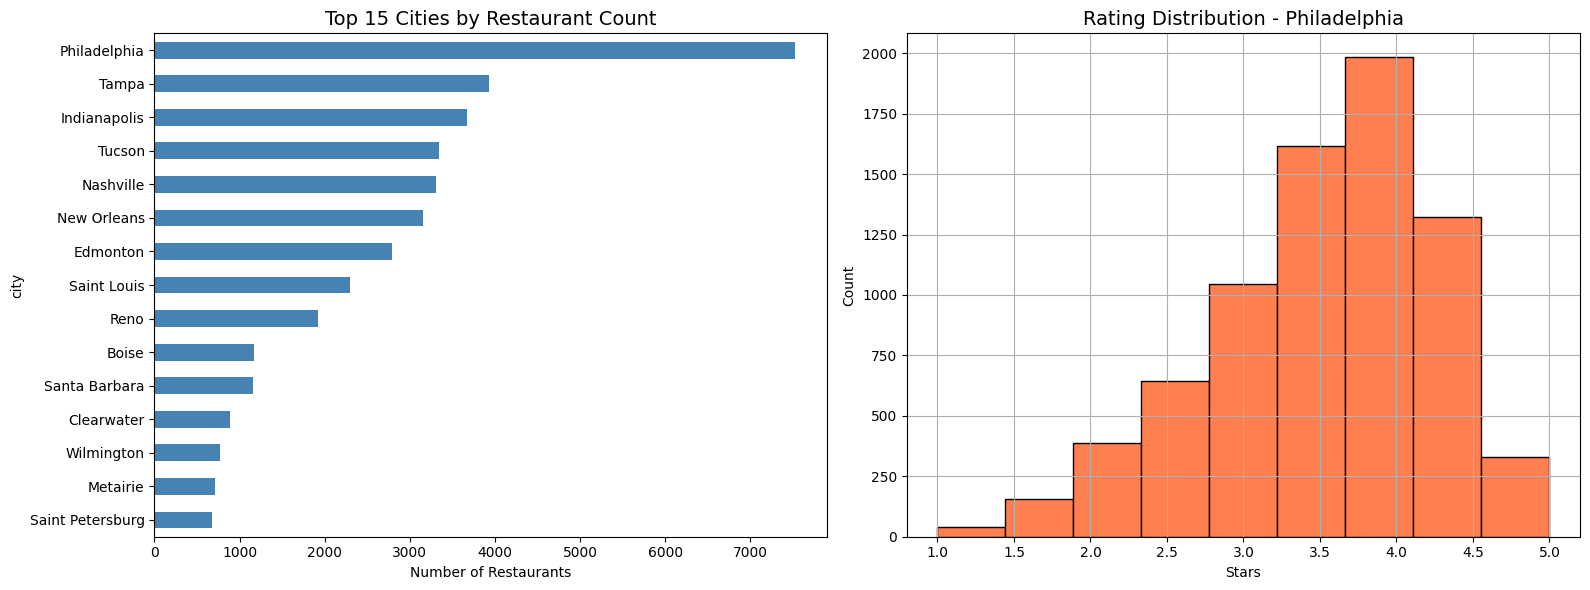

✅ Saved: 01_business_overview.png


In [7]:
# Section 1 plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

city_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Cities by Restaurant Count', fontsize=14)
axes[0].set_xlabel('Number of Restaurants')
axes[0].invert_yaxis()

city_restaurants['stars'].hist(bins=9, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title(f'Rating Distribution - {TARGET_CITY}', fontsize=14)
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_business_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: 01_business_overview.png')

In [8]:
# Category breakdown for target city
print(f'--- Top 20 Categories in {TARGET_CITY} ---')
all_cats = city_restaurants['categories'].fillna('').str.split(', ').explode()
print(all_cats.value_counts().head(20).to_string())

--- Top 20 Categories in Philadelphia ---
categories
Restaurants                  5852
Food                         3105
Nightlife                    1356
Bars                         1293
Sandwiches                    929
Coffee & Tea                  894
Pizza                         800
American (New)                751
Breakfast & Brunch            686
American (Traditional)        663
Italian                       505
Specialty Food                482
Chinese                       471
Event Planning & Services     391
Bakeries                      373
Fast Food                     367
Burgers                       363
Seafood                       359
Desserts                      344
Grocery                       329


## Section 2: Review Data — Bipartite Network Feasibility

In [9]:
print('=' * 70)
print('SECTION 2: REVIEW DATA - BIPARTITE NETWORK FEASIBILITY')
print('=' * 70)

# Optimized: filter as we read instead of loading all 7M reviews
city_biz_ids = set(city_restaurants['business_id'])
print(f'Scanning reviews and keeping only {TARGET_CITY} matches...')
print(f'  (Matching against {len(city_biz_ids):,} restaurant IDs)')

city_review_rows = []
total_scanned = 0
hb = Heartbeat('Scanning reviews', interval=10)
hb.start()

with open(REVIEW_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        total_scanned += 1
        record = json.loads(line)
        if record['business_id'] in city_biz_ids:
            city_review_rows.append(record)
        if total_scanned % 1_000_000 == 0:
            print(f'  \U0001f4d6 Scanned {total_scanned:,} reviews, found {len(city_review_rows):,} for {TARGET_CITY}')

hb.stop()
print(f'  Total scanned: {total_scanned:,}, kept: {len(city_review_rows):,}')

print('Converting to DataFrame...')
city_reviews = pd.DataFrame(city_review_rows)
del city_review_rows  # free memory
print(f'  \u2705 DataFrame ready: {len(city_reviews):,} rows')

SECTION 2: REVIEW DATA - BIPARTITE NETWORK FEASIBILITY
Scanning reviews and keeping only Philadelphia matches...
  (Matching against 7,528 restaurant IDs)
  📖 Scanned 1,000,000 reviews, found 120,811 for Philadelphia
  📖 Scanned 2,000,000 reviews, found 229,958 for Philadelphia
  💓 Scanning reviews... (10s elapsed)
  📖 Scanned 3,000,000 reviews, found 341,225 for Philadelphia
  📖 Scanned 4,000,000 reviews, found 442,984 for Philadelphia
  📖 Scanned 5,000,000 reviews, found 547,765 for Philadelphia
  💓 Scanning reviews... (20s elapsed)
  📖 Scanned 6,000,000 reviews, found 657,592 for Philadelphia
  ✅ Done! (25s)
  Total scanned: 6,990,280, kept: 761,928
Converting to DataFrame...
  ✅ DataFrame ready: 761,928 rows


In [10]:
# Section 2 stats
unique_reviewers = city_reviews['user_id'].nunique()
unique_restaurants = city_reviews['business_id'].nunique()

print('--- Bipartite Network Summary ---')
print(f'Unique reviewers: {unique_reviewers:,}')
print(f'Unique restaurants reviewed: {unique_restaurants:,}')
print(f'Bipartite edges (reviews): {len(city_reviews):,}')
print(f'Avg reviews per restaurant: {len(city_reviews)/unique_restaurants:.1f}')
print(f'Avg reviews per reviewer: {len(city_reviews)/unique_reviewers:.1f}')

city_reviews['date'] = pd.to_datetime(city_reviews['date'])
print(f'\nDate range: {city_reviews["date"].min()} to {city_reviews["date"].max()}')

--- Bipartite Network Summary ---
Unique reviewers: 221,955
Unique restaurants reviewed: 7,528
Bipartite edges (reviews): 761,928
Avg reviews per restaurant: 101.2
Avg reviews per reviewer: 3.4

Date range: 2005-02-16 04:06:26 to 2022-01-19 19:46:34


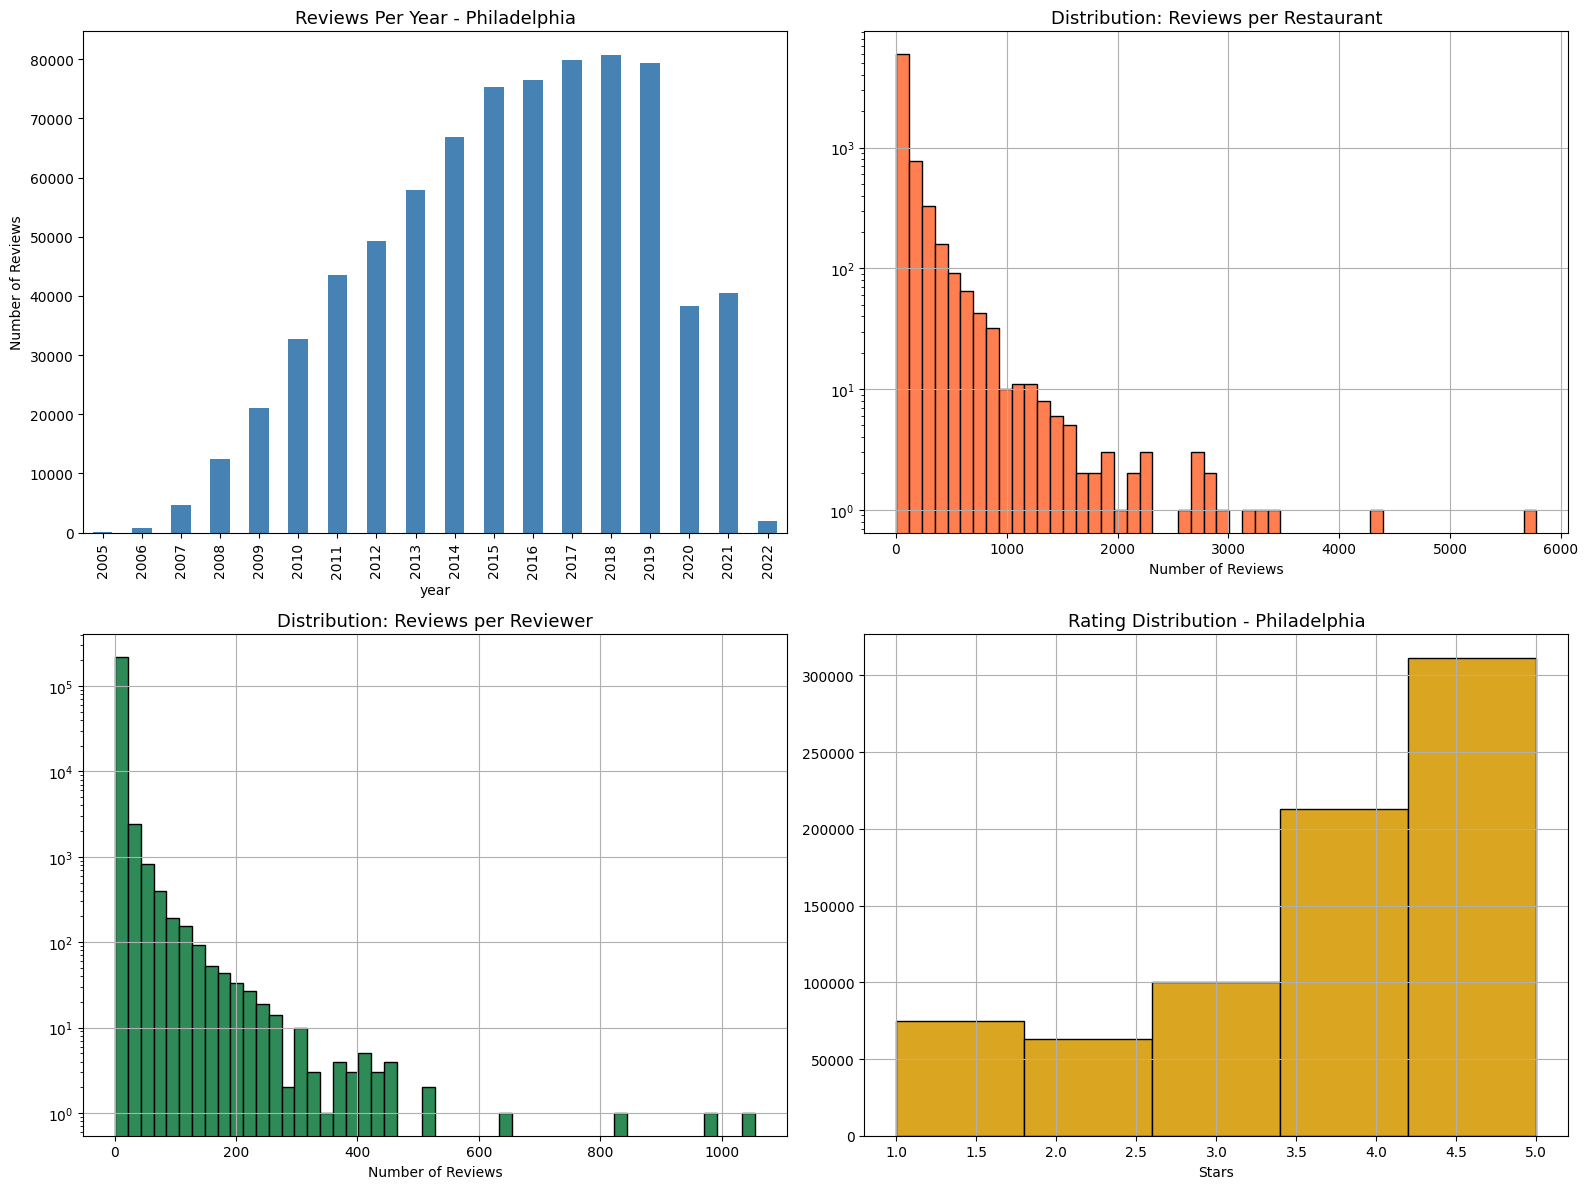

✅ Saved: 02_review_overview.png


In [11]:
# Section 2 plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

city_reviews['year'] = city_reviews['date'].dt.year
city_reviews.groupby('year').size().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title(f'Reviews Per Year - {TARGET_CITY}', fontsize=13)
axes[0,0].set_ylabel('Number of Reviews')

reviews_per_restaurant = city_reviews.groupby('business_id').size()
reviews_per_restaurant.hist(bins=50, ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Distribution: Reviews per Restaurant', fontsize=13)
axes[0,1].set_xlabel('Number of Reviews')
axes[0,1].set_yscale('log')

reviews_per_reviewer = city_reviews.groupby('user_id').size()
reviews_per_reviewer.hist(bins=50, ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Distribution: Reviews per Reviewer', fontsize=13)
axes[1,0].set_xlabel('Number of Reviews')
axes[1,0].set_yscale('log')

city_reviews['stars'].hist(bins=5, ax=axes[1,1], color='goldenrod', edgecolor='black')
axes[1,1].set_title(f'Rating Distribution - {TARGET_CITY}', fontsize=13)
axes[1,1].set_xlabel('Stars')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_review_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: 02_review_overview.png')

## Section 3: User & Friend Network — Social Ties

In [12]:
print('=' * 70)
print('SECTION 3: USER / FRIEND NETWORK - SOCIAL TIES')
print('=' * 70)

# Optimized: only load users who reviewed in our city
city_user_ids = set(city_reviews['user_id'])
print(f'Loading users and filtering to {len(city_user_ids):,} {TARGET_CITY} reviewers...')

city_user_rows = []
total_scanned = 0
hb = Heartbeat('Scanning users', interval=10)
hb.start()

with open(USER_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        total_scanned += 1
        record = json.loads(line)
        if record['user_id'] in city_user_ids:
            city_user_rows.append(record)
        if total_scanned % 500_000 == 0:
            print(f'  \U0001f4d6 Scanned {total_scanned:,} users, matched {len(city_user_rows):,}')

hb.stop()
print(f'  Total scanned: {total_scanned:,}, matched: {len(city_user_rows):,}')

city_users = pd.DataFrame(city_user_rows)
del city_user_rows
print(f'\u2705 Loaded {len(city_users):,} users who reviewed in {TARGET_CITY}')

SECTION 3: USER / FRIEND NETWORK - SOCIAL TIES
Loading users and filtering to 221,955 Philadelphia reviewers...
  📖 Scanned 500,000 users, matched 85,283
  📖 Scanned 1,000,000 users, matched 143,077
  💓 Scanning users... (10s elapsed)
  📖 Scanned 1,500,000 users, matched 186,825
  ✅ Done! (13s)
  Total scanned: 1,987,897, matched: 221,955
✅ Loaded 221,955 users who reviewed in Philadelphia


In [13]:
# Parse friend lists
def count_friends(friends_field):
    if isinstance(friends_field, list):
        return len(friends_field)
    if isinstance(friends_field, str) and friends_field.strip() and friends_field.strip() != 'None':
        return len(friends_field.split(', '))
    return 0

def get_friend_list(friends_field):
    if isinstance(friends_field, list):
        return friends_field
    if isinstance(friends_field, str) and friends_field.strip() and friends_field.strip() != 'None':
        return friends_field.split(', ')
    return []

print('Parsing friend lists...')
city_users['friend_count'] = city_users['friends'].apply(count_friends)
city_users['friend_list'] = city_users['friends'].apply(get_friend_list)

print(f'\n--- Friend Network Stats for {TARGET_CITY} Reviewers ---')
print(f'Users with at least 1 friend: {(city_users["friend_count"] > 0).sum():,} ({(city_users["friend_count"] > 0).mean()*100:.1f}%)')
print(f'Users with 0 friends: {(city_users["friend_count"] == 0).sum():,}')
print(f'Mean friends per user: {city_users["friend_count"].mean():.1f}')
print(f'Median friends per user: {city_users["friend_count"].median():.0f}')
print(f'Max friends: {city_users["friend_count"].max():,}')
print(f'Users with 10+ friends: {(city_users["friend_count"] >= 10).sum():,}')
print(f'Users with 50+ friends: {(city_users["friend_count"] >= 50).sum():,}')

Parsing friend lists...

--- Friend Network Stats for Philadelphia Reviewers ---
Users with at least 1 friend: 140,689 (63.4%)
Users with 0 friends: 81,266
Mean friends per user: 69.3
Median friends per user: 4
Max friends: 14,995
Users with 10+ friends: 96,518
Users with 50+ friends: 62,677


In [14]:
# CRITICAL CHECK: How many friends are ALSO in our city reviewer set?
print('--- CRITICAL CHECK: Internal Friend Connections ---')
print('Counting internal edges (both users reviewed in city)...')

hb = Heartbeat('Counting friend edges', interval=10)
hb.start()

all_friend_ids = set()
internal_edge_count = 0
for idx, (_, row) in enumerate(city_users.iterrows()):
    for fid in row['friend_list']:
        all_friend_ids.add(fid)
        if fid in city_user_ids:
            internal_edge_count += 1
    if (idx + 1) % 10000 == 0:
        print(f'  Processed {idx+1:,}/{len(city_users):,} users...')

internal_edge_count = internal_edge_count // 2  # undirected
hb.stop()

internal_friends = all_friend_ids.intersection(city_user_ids)
print(f'\nTotal unique friend IDs referenced: {len(all_friend_ids):,}')
print(f'Friend IDs that are ALSO {TARGET_CITY} reviewers: {len(internal_friends):,}')
print(f'Overlap rate: {len(internal_friends)/max(len(all_friend_ids),1)*100:.1f}%')
print(f'\nInternal friend edges: {internal_edge_count:,}')
print(f'Social network: {len(city_user_ids):,} nodes, {internal_edge_count:,} edges')

--- CRITICAL CHECK: Internal Friend Connections ---
Counting internal edges (both users reviewed in city)...
  Processed 10,000/221,955 users...
  Processed 20,000/221,955 users...
  Processed 30,000/221,955 users...
  Processed 40,000/221,955 users...
  Processed 50,000/221,955 users...
  Processed 60,000/221,955 users...
  Processed 70,000/221,955 users...
  Processed 80,000/221,955 users...
  Processed 90,000/221,955 users...
  Processed 100,000/221,955 users...
  Processed 110,000/221,955 users...
  Processed 120,000/221,955 users...
  Processed 130,000/221,955 users...
  Processed 140,000/221,955 users...
  Processed 150,000/221,955 users...
  Processed 160,000/221,955 users...
  Processed 170,000/221,955 users...
  Processed 180,000/221,955 users...
  Processed 190,000/221,955 users...
  Processed 200,000/221,955 users...
  Processed 210,000/221,955 users...
  Processed 220,000/221,955 users...
  ✅ Done! (9s)

Total unique friend IDs referenced: 5,793,317
Friend IDs that are ALSO

Elite users in Philadelphia: 21,085 (9.5%)


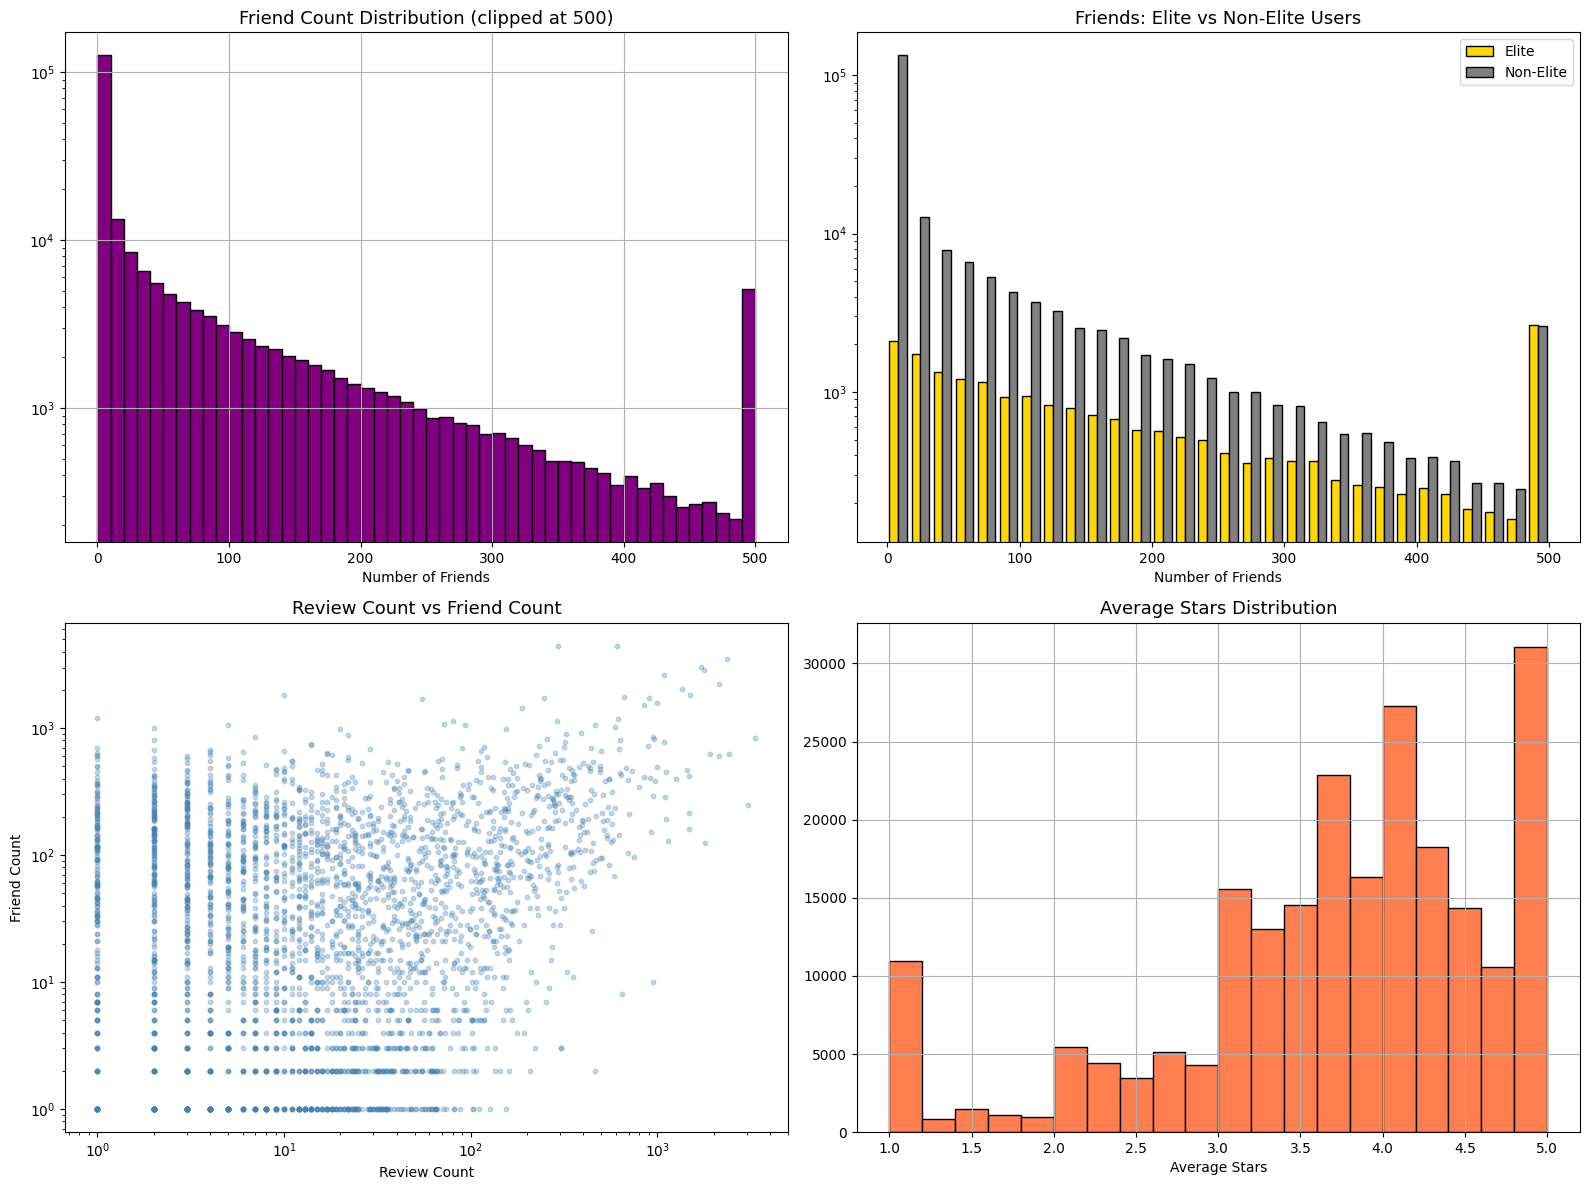

✅ Saved: 03_user_friend_network.png


In [15]:
# Elite users
city_users['is_elite'] = city_users['elite'].apply(
    lambda x: len(x) > 0 if isinstance(x, list) else (len(str(x).strip()) > 0 and str(x).strip() != 'None')
)
print(f'Elite users in {TARGET_CITY}: {city_users["is_elite"].sum():,} ({city_users["is_elite"].mean()*100:.1f}%)')

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

city_users['friend_count'].clip(upper=500).hist(bins=50, ax=axes[0,0], color='purple', edgecolor='black')
axes[0,0].set_title('Friend Count Distribution (clipped at 500)', fontsize=13)
axes[0,0].set_xlabel('Number of Friends')
axes[0,0].set_yscale('log')

elite = city_users[city_users['is_elite']==True]['friend_count'].clip(upper=500)
non_elite = city_users[city_users['is_elite']==False]['friend_count'].clip(upper=500)
axes[0,1].hist([elite, non_elite], bins=30, label=['Elite', 'Non-Elite'], color=['gold', 'gray'], edgecolor='black')
axes[0,1].set_title('Friends: Elite vs Non-Elite Users', fontsize=13)
axes[0,1].set_xlabel('Number of Friends')
axes[0,1].legend()
axes[0,1].set_yscale('log')

sample = city_users.sample(min(5000, len(city_users)), random_state=42)
axes[1,0].scatter(sample['review_count'], sample['friend_count'], alpha=0.3, s=10, c='steelblue')
axes[1,0].set_title('Review Count vs Friend Count', fontsize=13)
axes[1,0].set_xlabel('Review Count')
axes[1,0].set_ylabel('Friend Count')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')

city_users['average_stars'].hist(bins=20, ax=axes[1,1], color='coral', edgecolor='black')
axes[1,1].set_title('Average Stars Distribution', fontsize=13)
axes[1,1].set_xlabel('Average Stars')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_user_friend_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: 03_user_friend_network.png')

## Section 4: Feasibility Summary

In [16]:
print('=' * 70)
print('SECTION 4: FEASIBILITY SUMMARY')
print('=' * 70)

print(f'''
========================================================
          PROJECT FEASIBILITY REPORT
========================================================
 Target City:          {TARGET_CITY}

 BIPARTITE NETWORK (Reviewer <-> Restaurant)
   Restaurants:         {unique_restaurants:,}
   Reviewers:           {unique_reviewers:,}
   Edges (reviews):     {len(city_reviews):,}

 SOCIAL NETWORK (Friend <-> Friend)
   Nodes:               {len(city_user_ids):,}
   Internal Edges:      {internal_edge_count:,}
   Users w/ friends:    {(city_users["friend_count"] > 0).sum():,}

 TEMPORAL DATA
   Date Range:          {city_reviews["date"].min().date()} to {city_reviews["date"].max().date()}
   Elite Users:         {city_users["is_elite"].sum():,}
========================================================
''')

# Verdict
if unique_restaurants >= 200 and internal_edge_count >= 1000 and unique_reviewers >= 2000:
    print('VERDICT: \u2705 PROJECT IS FEASIBLE - Strong data for all analyses')
elif unique_restaurants >= 100 and internal_edge_count >= 500:
    print('VERDICT: \u26a0\ufe0f  FEASIBLE WITH CAVEATS - May need to relax filters')
else:
    print('VERDICT: \u274c CONSIDER DIFFERENT CITY - Not enough data')

SECTION 4: FEASIBILITY SUMMARY

          PROJECT FEASIBILITY REPORT
 Target City:          Philadelphia

 BIPARTITE NETWORK (Reviewer <-> Restaurant)
   Restaurants:         7,528
   Reviewers:           221,955
   Edges (reviews):     761,928

 SOCIAL NETWORK (Friend <-> Friend)
   Nodes:               221,955
   Internal Edges:      669,794
   Users w/ friends:    140,689

 TEMPORAL DATA
   Date Range:          2005-02-16 to 2022-01-19
   Elite Users:         21,085

VERDICT: ✅ PROJECT IS FEASIBLE - Strong data for all analyses


## Section 5: Quick Network Preview

In [17]:
print('=' * 70)
print('SECTION 5: QUICK NETWORK PREVIEW')
print('=' * 70)

import networkx as nx

# Sample social network (top 500 most-connected users)
print('\nBuilding sample social network (top 500 most-connected users)...')
top_users = city_users.nlargest(500, 'friend_count')
top_user_ids = set(top_users['user_id'])

G_social = nx.Graph()
for _, row in top_users.iterrows():
    uid = row['user_id']
    for fid in row['friend_list']:
        if fid in top_user_ids:
            G_social.add_edge(uid, fid)

print(f'Sample social network: {G_social.number_of_nodes()} nodes, {G_social.number_of_edges()} edges')
print(f'Density: {nx.density(G_social):.4f}')
print(f'Connected components: {nx.number_connected_components(G_social)}')

if G_social.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G_social), key=len)
    print(f'Largest component size: {len(largest_cc)}')

# Sample bipartite network
print('\nBuilding sample bipartite network (top 100 restaurants)...')
top_restaurants = city_reviews.groupby('business_id').size().nlargest(100).index
sample_reviews = city_reviews[city_reviews['business_id'].isin(top_restaurants)]

B = nx.Graph()
for _, row in sample_reviews.iterrows():
    B.add_node(row['user_id'], bipartite=0)
    B.add_node(row['business_id'], bipartite=1)
    B.add_edge(row['user_id'], row['business_id'])

reviewers_in_B = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 0}
restaurants_in_B = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 1}
print(f'Sample bipartite: {len(reviewers_in_B)} reviewers, {len(restaurants_in_B)} restaurants, {B.number_of_edges()} edges')

print('\n\u2705 NetworkX works! Ready for full analysis.')

SECTION 5: QUICK NETWORK PREVIEW

Building sample social network (top 500 most-connected users)...
Sample social network: 488 nodes, 21639 edges
Density: 0.1821
Connected components: 1
Largest component size: 488

Building sample bipartite network (top 100 restaurants)...
Sample bipartite: 75987 reviewers, 99 restaurants, 144817 edges

✅ NetworkX works! Ready for full analysis.


## Section 6: Homophily Preview — Do friends share restaurant taste?

In [18]:
print('=' * 70)
print('SECTION 6: HOMOPHILY PREVIEW')
print('=' * 70)

# Build user -> restaurants mapping
print('Building user-restaurant mapping...')
user_restaurants = city_reviews.groupby('user_id')['business_id'].apply(set).to_dict()

# Sample users with friends
users_with_friends = city_users[city_users['friend_count'] > 0]
sample_size = min(1000, len(users_with_friends))
sample_users = users_with_friends.sample(sample_size, random_state=42)

print(f'Checking restaurant overlap for {sample_size} users and their friends...')
hb = Heartbeat('Analyzing homophily', interval=10)
hb.start()

overlaps = []
for idx, (_, row) in enumerate(sample_users.iterrows()):
    uid = row['user_id']
    if uid not in user_restaurants:
        continue
    my_restaurants = user_restaurants[uid]

    for fid in row['friend_list'][:10]:  # first 10 friends for speed
        if fid in user_restaurants:
            friend_restaurants = user_restaurants[fid]
            if len(my_restaurants) > 0 and len(friend_restaurants) > 0:
                overlap = len(my_restaurants & friend_restaurants)
                jaccard = overlap / len(my_restaurants | friend_restaurants)
                overlaps.append({
                    'user': uid, 'friend': fid,
                    'overlap_count': overlap,
                    'jaccard_similarity': jaccard,
                })
    if (idx + 1) % 200 == 0:
        print(f'  Processed {idx+1}/{sample_size} users, {len(overlaps)} pairs found...')

hb.stop()

SECTION 6: HOMOPHILY PREVIEW
Building user-restaurant mapping...
Checking restaurant overlap for 1000 users and their friends...
  Processed 200/1000 users, 227 pairs found...
  Processed 400/1000 users, 391 pairs found...
  Processed 600/1000 users, 583 pairs found...
  Processed 800/1000 users, 807 pairs found...
  Processed 1000/1000 users, 1007 pairs found...
  ✅ Done! (0s)


Friend pairs analyzed: 1,007
Mean Jaccard similarity (friends): 0.0091
Pairs with ANY shared restaurant: 161 (16.0%)

--- Comparing Friends vs Random Pairs (Homophily Test) ---
Friends avg Jaccard:  0.0091
Random avg Jaccard:   0.0008
Friends/Random ratio: 11.07x
✅ STRONG homophily signal - friends share significantly more restaurants!


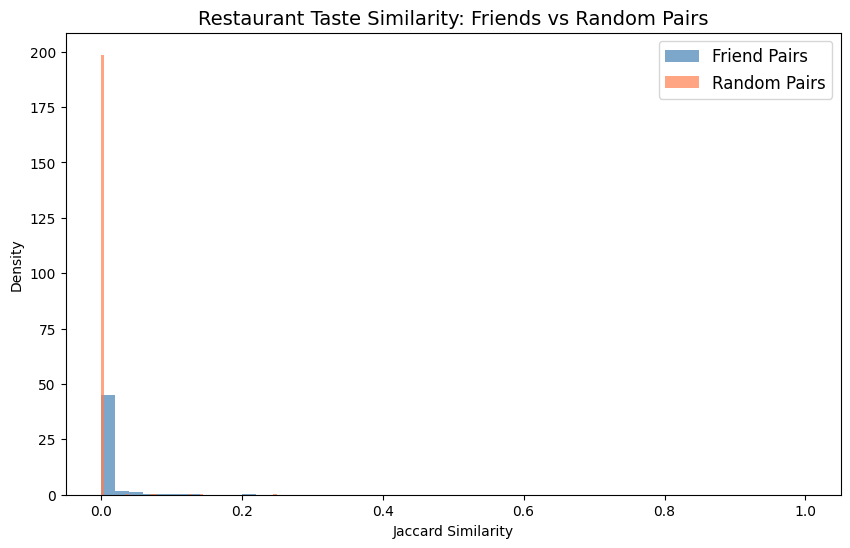

✅ Saved: 04_homophily_preview.png


In [19]:
# Compare friends vs random pairs
if overlaps:
    overlap_df = pd.DataFrame(overlaps)
    print(f'Friend pairs analyzed: {len(overlap_df):,}')
    print(f'Mean Jaccard similarity (friends): {overlap_df["jaccard_similarity"].mean():.4f}')
    print(f'Pairs with ANY shared restaurant: {(overlap_df["overlap_count"] > 0).sum():,} ({(overlap_df["overlap_count"] > 0).mean()*100:.1f}%)')

    # Random baseline
    print('\n--- Comparing Friends vs Random Pairs (Homophily Test) ---')
    all_user_ids_list = list(user_restaurants.keys())
    rng = np.random.RandomState(42)
    random_overlaps = []
    for _ in range(min(5000, len(overlaps))):
        u1, u2 = rng.choice(all_user_ids_list, 2, replace=False)
        r1, r2 = user_restaurants[u1], user_restaurants[u2]
        if len(r1) > 0 and len(r2) > 0:
            jaccard = len(r1 & r2) / len(r1 | r2)
            random_overlaps.append(jaccard)

    print(f'Friends avg Jaccard:  {overlap_df["jaccard_similarity"].mean():.4f}')
    print(f'Random avg Jaccard:   {np.mean(random_overlaps):.4f}')
    ratio = overlap_df['jaccard_similarity'].mean() / max(np.mean(random_overlaps), 0.0001)
    print(f'Friends/Random ratio: {ratio:.2f}x')

    if ratio > 1.5:
        print('\u2705 STRONG homophily signal - friends share significantly more restaurants!')
    elif ratio > 1.1:
        print('\u26a0\ufe0f  Moderate homophily signal')
    else:
        print('\u274c Weak homophily signal')

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.hist(overlap_df['jaccard_similarity'], bins=50, alpha=0.7, label='Friend Pairs', color='steelblue', density=True)
    ax.hist(random_overlaps, bins=50, alpha=0.7, label='Random Pairs', color='coral', density=True)
    ax.set_title('Restaurant Taste Similarity: Friends vs Random Pairs', fontsize=14)
    ax.set_xlabel('Jaccard Similarity')
    ax.set_ylabel('Density')
    ax.legend(fontsize=12)
    plt.savefig(OUTPUT_DIR + '04_homophily_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\u2705 Saved: 04_homophily_preview.png')
else:
    print('\u26a0\ufe0f Not enough friend overlap data')

## Section 7: Next Steps

In [20]:
print('=' * 70)
print('NEXT STEPS')
print('=' * 70)
print(f'''
If {TARGET_CITY} looks good, build:

  a) Full bipartite network (reviewer <-> restaurant)
  b) Projected unipartite network (restaurant <-> restaurant via shared reviewers)
  c) Social friend network (reviewer <-> reviewer)
  d) Centrality analysis (degree, betweenness, eigenvector)
  e) Community detection (Louvain)
  f) Homophily vs Influence testing with timestamps
  g) K-core analysis for "elite foodie" detection

Plots saved to: {OUTPUT_DIR}
''')

NEXT STEPS

If Philadelphia looks good, build:

  a) Full bipartite network (reviewer <-> restaurant)
  b) Projected unipartite network (restaurant <-> restaurant via shared reviewers)
  c) Social friend network (reviewer <-> reviewer)
  d) Centrality analysis (degree, betweenness, eigenvector)
  e) Community detection (Louvain)
  f) Homophily vs Influence testing with timestamps
  g) K-core analysis for "elite foodie" detection

Plots saved to: /Users/andykim/Desktop/yelp_eda_output/

